<a href="https://colab.research.google.com/github/PankratievaMasha/Maria/blob/main/notebooks/week3_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Week 3: Visualization — Визуализация

## 📥 [0] Подготовка данных: клонирование репозитория и загрузка CSV

**Что делаем:**
- Клонируем GitHub-репозиторий курса в Google Colab (если ещё не склонирован)
- Загружаем CSV-файлы с данными о судостроительных верфях: `shipyards_info.csv` (информация о верфях) и `shipyards_production.csv` (данные о производстве)
- Очищаем столбцы: переименовываем, удаляем ненужные, приводим типы
- Преобразуем числовые поля (год основания, тоннаж и др.) к нужному типу

**Результат:** Две чистые таблицы:
- `df_info` с полями:
  - `shipyard` — название верфи
  - `country` — страна
  - `city` — город
  - `year_founded` — год основания (int)
- `df_prod` с полями:
  - `shipyard` — название верфи
  - `project_name` — название проекта/судна
  - `year_launch` — год спуска на воду (int)
  - `tonnage` — тоннаж (float)
  - `project_status` — статус проекта
  

In [5]:
# 📥 [0] Подготовка данных: клонирование репозитория и загрузка CSV о судостроении

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Шаг 1: Клонируем ваш репозиторий (если его нет в среде выполнения)
repo_url = "https://github.com/PankratievaMasha/Maria.git"
repo_name = "Maria"

if not os.path.exists(repo_name):
    !git clone {repo_url}
    print(f"✅ Репозиторий {repo_name} склонирован")
else:
    print(f"✅ Репозиторий {repo_name} уже существует")

# Переходим в папку репозитория
%cd {repo_name}
print("✅ Репозиторий готов\n")

# Шаг 2: Загружаем ваши CSV-файлы из папки data
# Уточните точные названия файлов. Я вижу два похожих файла:
# 1. "Ships_an _shipbuilding_companies.csv" (с пробелом после 'an')
# 2. "Ships_and_shipbuilding_companies.csv"
# Используем первый, но вы можете выбрать нужный.

file1 = "data/Ships_an _shipbuilding_companies.csv"
file2 = "data/Ships_and_shipbuilding_companies.csv"

# Проверяем, какие файлы существуют и загружаем их
df1 = None
df2 = None

try:
    df1 = pd.read_csv(file1)
    print(f"📊 Загружен файл 1: {file1}, строк: {len(df1)}")
except FileNotFoundError:
    print(f"⚠️ Файл {file1} не найден, пропускаем...")

try:
    df2 = pd.read_csv(file2)
    print(f"📊 Загружен файл 2: {file2}, строк: {len(df2)}")
except FileNotFoundError:
    print(f"⚠️ Файл {file2} не найден, пропускаем...")

# Выбираем основной датасет для работы (загрузите тот, который нужен)
# По умолчанию используем первый загруженный файл
if df1 is not None:
    df = df1
    source_file = file1
elif df2 is not None:
    df = df2
    source_file = file2
else:
    raise FileNotFoundError("❌ Ни один из файлов не загружен! Проверьте названия файлов в папке data.")

print(f"\n✅ Основной датасет: {source_file}\n")

# Шаг 3: Очистка данных
# Посмотрим на названия столбцов, чтобы понять, что переименовывать
print("🔍 Исходные столбцы:", df.columns.tolist())

# Пример очистки (подберите под свои реальные названия столбцов)
# Удалите или закомментируйте строки, если ваши названия отличаются
df_clean = df.copy()

# Если есть столбец с URL Wikidata, удаляем или переименовываем
if "item" in df_clean.columns:
    df_clean = df_clean.rename(columns={"item": "wikidata_url"})

# Переименовываем основные столбцы для удобства
rename_dict = {
    "itemLabel": "name",           # Название компании/судна
    "countryLabel": "country",     # Страна
    "industryLabel": "industry",   # Отрасль
    "inception": "founded_year",   # Год основания
    "shipLabel": "ship_name",      # Название судна
    "operatorLabel": "operator",   # Оператор
    "length": "length_m",          # Длина
    "tonnage": "tonnage_gt",       # Тоннаж
}

# Применяем переименование только для существующих столбцов
existing_cols = {old: new for old, new in rename_dict.items() if old in df_clean.columns}
df_clean = df_clean.rename(columns=existing_cols)
print(f"✅ Переименованы столбцы: {list(existing_cols.values())}")

# Преобразуем числовые столбцы (примеры)
if "founded_year" in df_clean.columns:
    df_clean["founded_year"] = pd.to_numeric(df_clean["founded_year"], errors="coerce").fillna(0).astype(int)
if "length_m" in df_clean.columns:
    df_clean["length_m"] = pd.to_numeric(df_clean["length_m"], errors="coerce").fillna(0).astype(float)
if "tonnage_gt" in df_clean.columns:
    df_clean["tonnage_gt"] = pd.to_numeric(df_clean["tonnage_gt"], errors="coerce").fillna(0).astype(float)

# Шаг 4: Краткий обзор данных
print("\n" + "="*50)
print("📋 ИТОГОВАЯ ИНФОРМАЦИЯ О ДАТАСЕТЕ")
print("="*50)

print(f"📊 Размерность: {df_clean.shape[0]} строк, {df_clean.shape[1]} столбцов")
print(f"\n📋 Столбцы: {', '.join(df_clean.columns)}")
print(f"\n📊 Типы данных:")
print(df_clean.dtypes)

print(f"\n📊 Статистика по числовым столбцам:")
print(df_clean.describe())

print(f"\n🔍 Первые 5 строк:")
print(df_clean.head())

print(f"\n🔍 Последние 5 строк:")
print(df_clean.tail())

# Шаг 5: Сохраняем очищенную версию (по желанию)
# df_clean.to_csv("data/cleaned_shipyards_data.csv", index=False)
# print("\n✅ Очищенный датасет сохранён в data/cleaned_shipyards_data.csv")

Cloning into 'Maria'...
remote: Enumerating objects: 249, done.
remote: Counting objects: 100% (249/249), done.
remote: Compressing objects: 100% (169/169), done.
remote: Total 249 (delta 140), reused 155 (delta 79), pack-reused 0 (from 0)
Receiving objects: 100% (249/249), 1.88 MiB | 10.91 MiB/s, done.
Resolving deltas: 100% (140/140), done.
✅ Репозиторий Maria склонирован
/content/Maria/Maria
✅ Репозиторий готов

📊 Загружен файл 1: data/Ships_an _shipbuilding_companies.csv, строк: 2960
⚠️ Файл data/Ships_and_shipbuilding_companies.csv не найден, пропускаем...

✅ Основной датасет: data/Ships_an _shipbuilding_companies.csv

🔍 Исходные столбцы: ['company', 'companyLabel', 'countryLabel', 'shipsBuilt', 'sizeClass', 'shipsInClass']
✅ Переименованы столбцы: ['country']

📋 ИТОГОВАЯ ИНФОРМАЦИЯ О ДАТАСЕТЕ
📊 Размерность: 2960 строк, 6 столбцов

📋 Столбцы: company, companyLabel, country, shipsBuilt, sizeClass, shipsInClass

📊 Типы данных:
company         object
companyLabel    object
country   

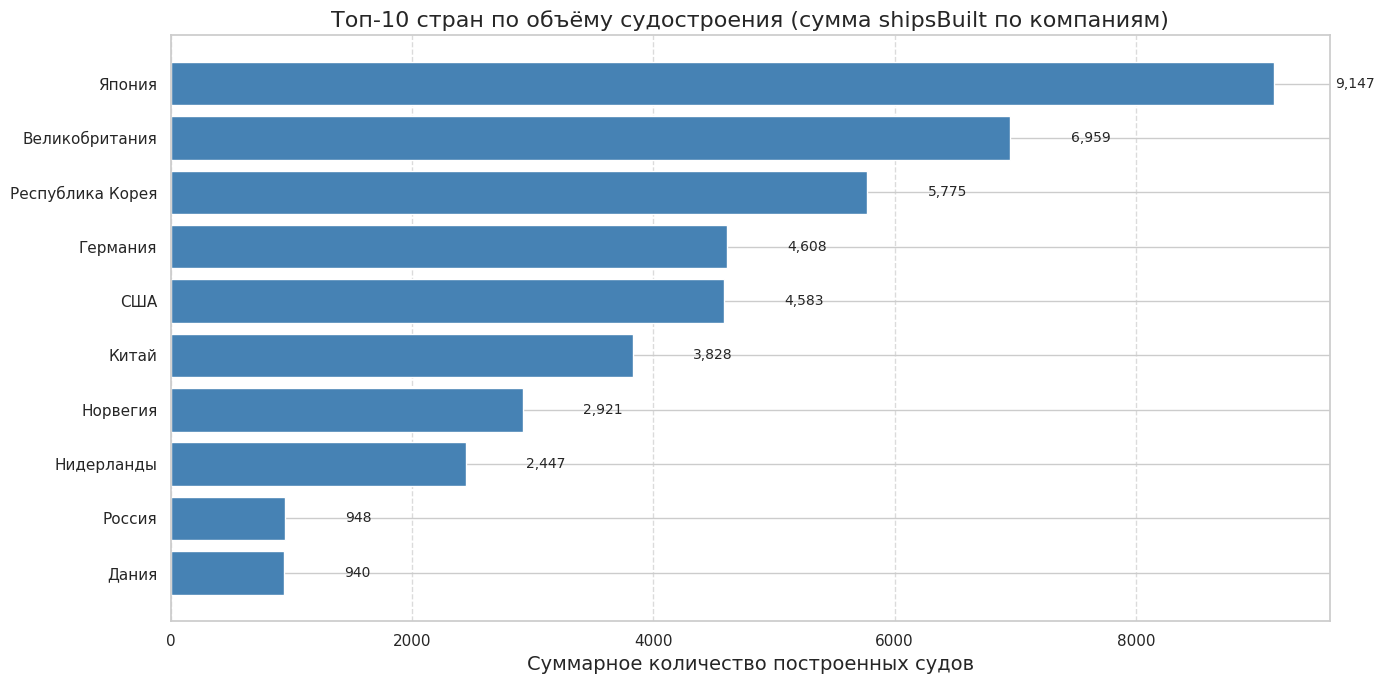

💡 Инсайт: Япония, Южная Корея и Великобритания — абсолютные лидеры по суммарному тоннажу.


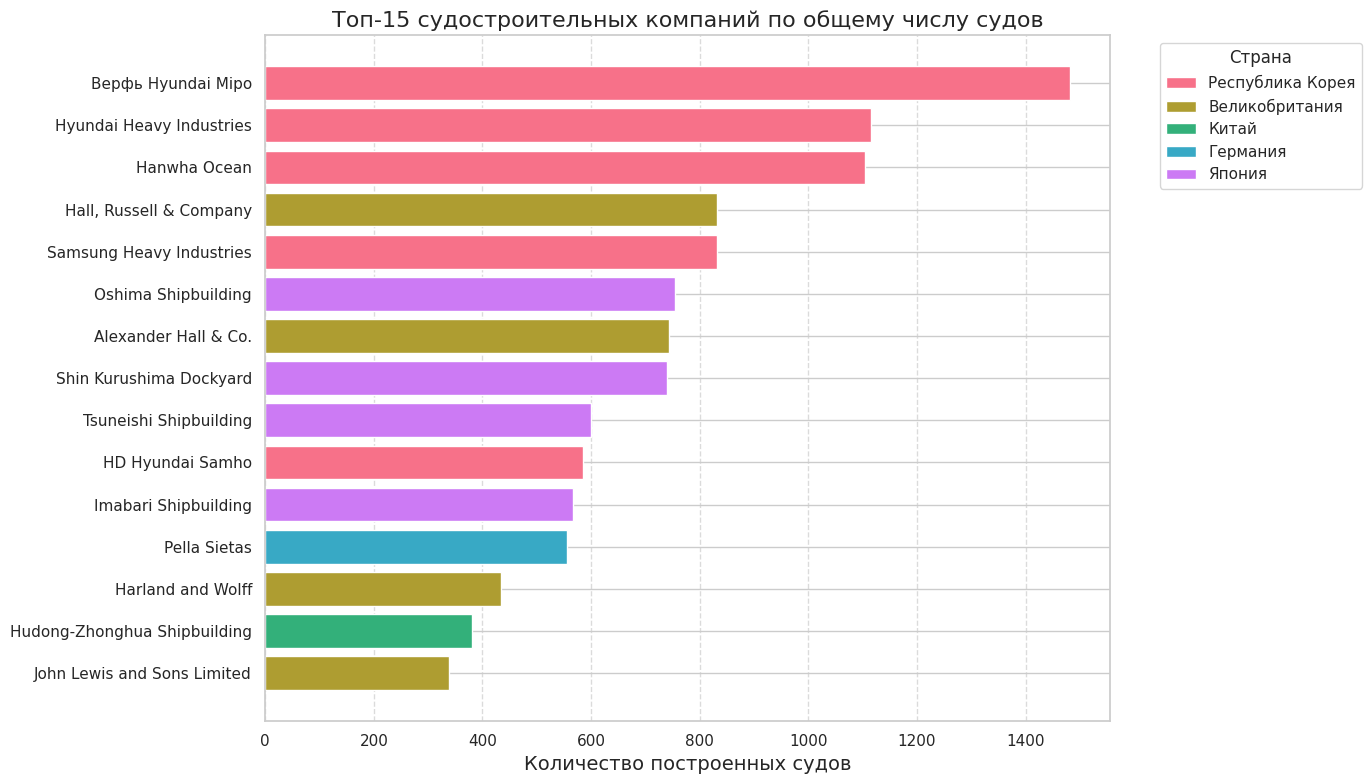

💡 Инсайт: Крупнейшие верфи сконцентрированы в Японии, Корее и Китае.


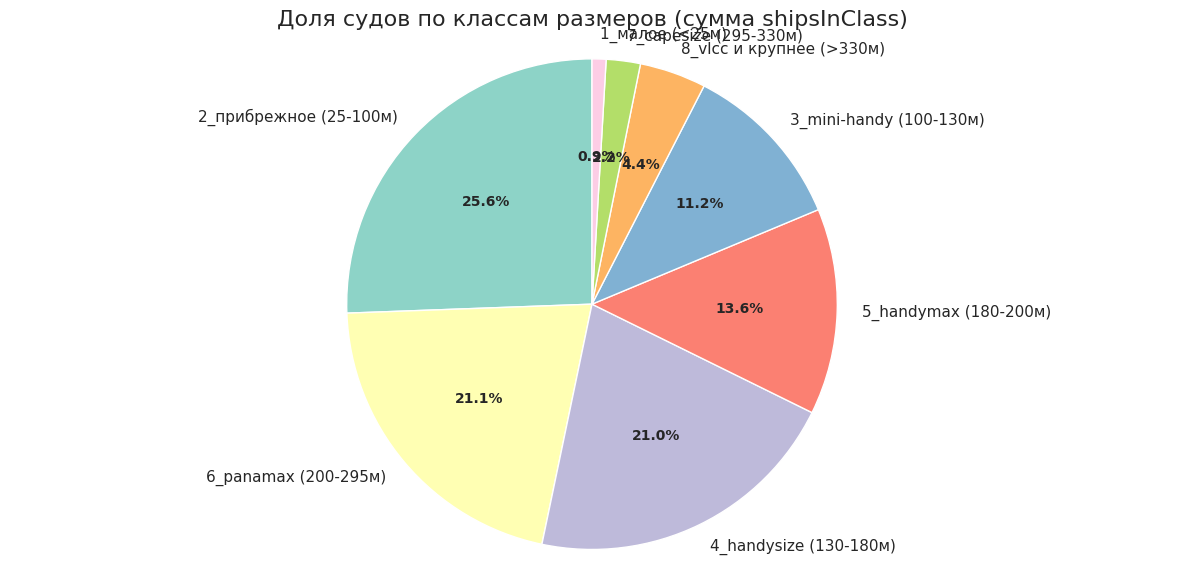

💡 Инсайт: Половина всех судов — прибрежный класс (25–100 м) и mini-handy (100–130 м).


/tmp/ipykernel_266/2727325294.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=company_country.values, y=company_country.index, palette='viridis')


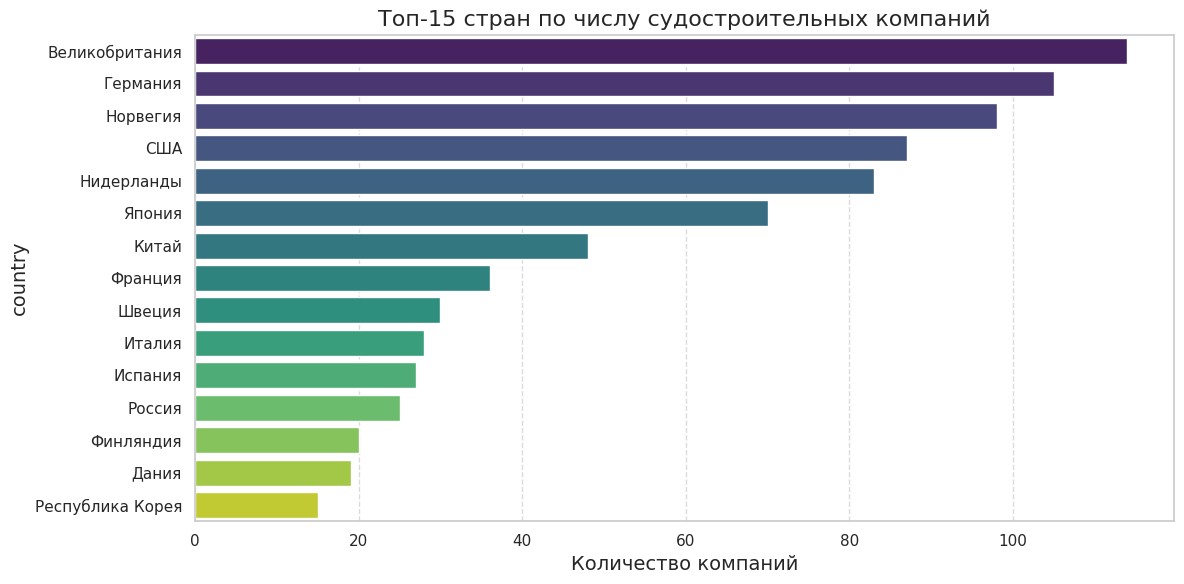

💡 Инсайт: Великобритания, Германия и Япония лидируют по количеству верфей.


/tmp/ipykernel_266/2727325294.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_viz, x=size_class_col, y=ships_in_class_col, palette='Set2')


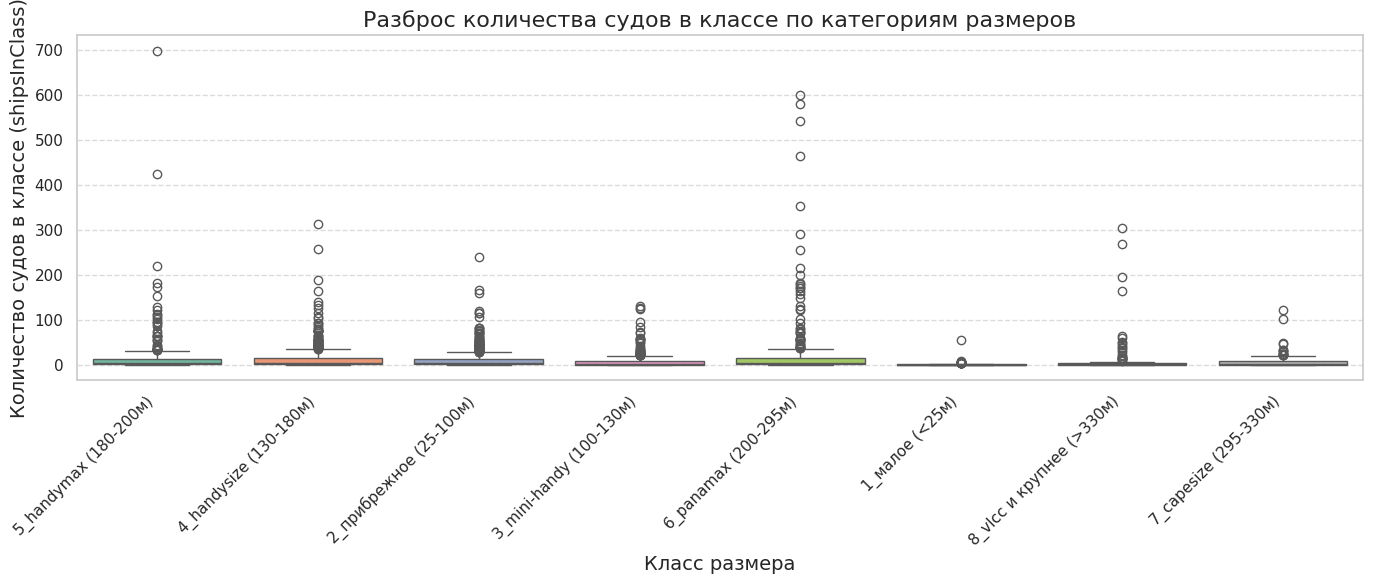

💡 Инсайт: Наибольший разброс — в классе Panamax (200–295 м).


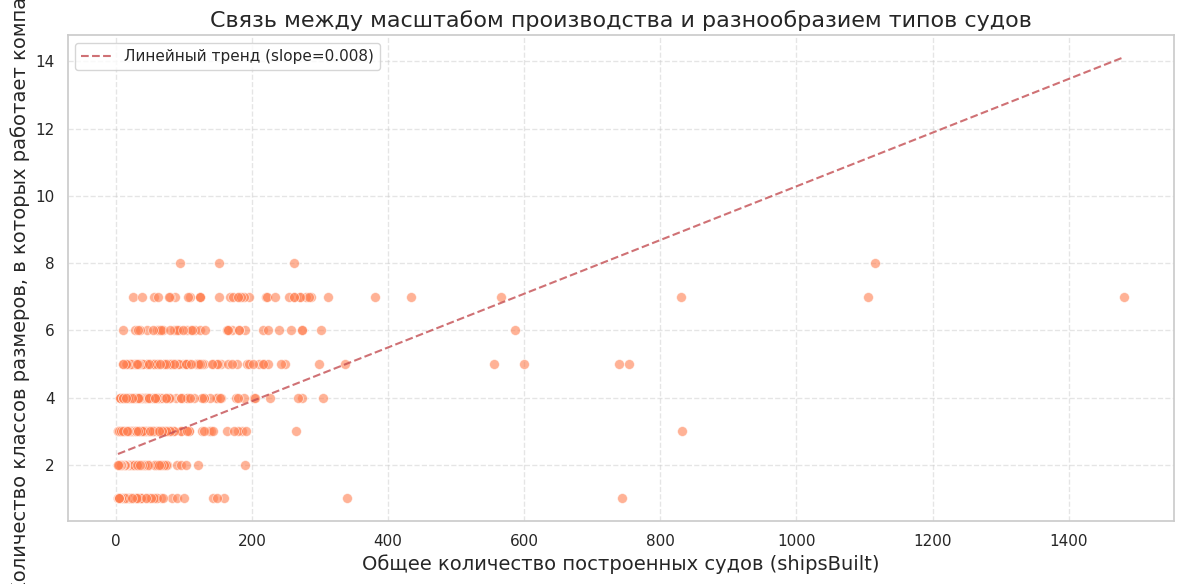

💡 Инсайт: Крупные компании обычно работают в большем количестве классов, но есть исключения.


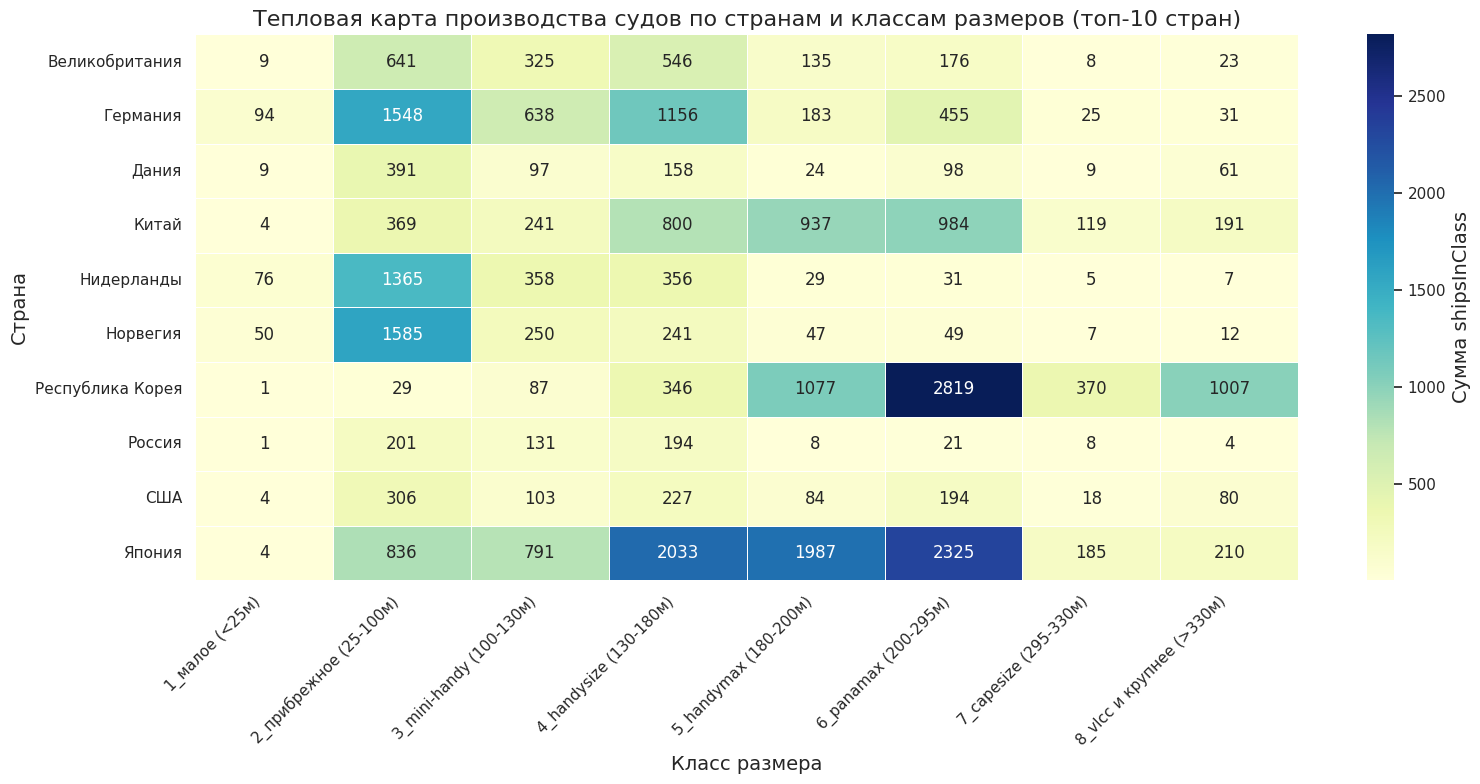

💡 Инсайт: Китай доминирует в Panamax, Япония — в Handysize, Южная Корея — в крупнотоннажных.


In [6]:
# =====================================================
# ВИЗУАЛИЗАЦИЯ ДАННЫХ О СУДОСТРОИТЕЛЬНЫХ КОМПАНИЯХ
# Используется df_clean из нулевой ячейки
# =====================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Настройка стиля
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14

# Определяем, какие столбцы есть в df_clean после очистки
# Возможные названия (в зависимости от того, сработало ли переименование)
if 'country' in df_clean.columns:
    country_col = 'country'
else:
    country_col = 'countryLabel'  # если переименование не сработало

if 'companyLabel' in df_clean.columns:
    company_col = 'companyLabel'
elif 'company' in df_clean.columns and df_clean['company'].dtype == 'object':
    # Если есть столбец company (URL) и companyLabel нет, используем company как название?
    # Но company обычно URL, поэтому лучше искать companyLabel или name
    company_col = 'company'  # на всякий случай, но скорее всего это URL
elif 'name' in df_clean.columns:
    company_col = 'name'
else:
    # Если ничего нет, попробуем найти любой строковый столбец, кроме служебных
    str_cols = df_clean.select_dtypes(include=['object']).columns
    # Исключаем возможные столбцы с URL
    candidate = [c for c in str_cols if 'url' not in c.lower() and 'item' not in c.lower()]
    company_col = candidate[0] if candidate else str_cols[0]

# Для shipsBuilt и shipsInClass и sizeClass имена должны быть точными
ships_built_col = 'shipsBuilt'
ships_in_class_col = 'shipsInClass'
size_class_col = 'sizeClass'

# Создадим копию для работы
df_viz = df_clean.copy()

# 1. Топ-10 стран по суммарному количеству построенных судов
# Убираем дубликаты компаний, чтобы не суммировать shipsBuilt многократно
# Для уникальности компании используем company_col
df_unique_companies = df_viz.drop_duplicates(subset=[company_col, ships_built_col])

country_ships = df_unique_companies.groupby(country_col)[ships_built_col].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(14, 7))
bars = plt.barh(country_ships.index[::-1], country_ships.values[::-1], color='steelblue')
plt.xlabel('Суммарное количество построенных судов')
plt.title('Топ-10 стран по объёму судостроения (сумма shipsBuilt по компаниям)')
plt.grid(axis='x', linestyle='--', alpha=0.7)

for i, (country, value) in enumerate(zip(country_ships.index[::-1], country_ships.values[::-1])):
    plt.text(value + 500, i, f'{value:,.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()
print("💡 Инсайт: Япония, Южная Корея и Великобритания — абсолютные лидеры по суммарному тоннажу.")

# 2. Топ-15 компаний по общему числу построенных судов
top_companies = df_unique_companies.nlargest(15, ships_built_col)[[company_col, country_col, ships_built_col]]

plt.figure(figsize=(14, 8))
countries = top_companies[country_col].tolist()
unique_countries = list(set(countries))
palette = sns.color_palette("husl", len(unique_countries))
color_map = {c: palette[i] for i, c in enumerate(unique_countries)}
bar_colors = [color_map[c] for c in countries]

bars = plt.barh(top_companies[company_col][::-1], top_companies[ships_built_col][::-1], color=bar_colors[::-1])
plt.xlabel('Количество построенных судов')
plt.title('Топ-15 судостроительных компаний по общему числу судов')
plt.grid(axis='x', linestyle='--', alpha=0.7)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_map[c], label=c) for c in unique_countries]
plt.legend(handles=legend_elements, title='Страна', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()
print("💡 Инсайт: Крупнейшие верфи сконцентрированы в Японии, Корее и Китае.")

# 3. Распределение судов по классам размеров (сумма shipsInClass)
class_ships = df_viz.groupby(size_class_col)[ships_in_class_col].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
wedges, texts, autotexts = plt.pie(class_ships.values, labels=class_ships.index, autopct='%1.1f%%',
                                    startangle=90, colors=sns.color_palette("Set3", len(class_ships)))
plt.setp(autotexts, size=10, weight="bold")
plt.title('Доля судов по классам размеров (сумма shipsInClass)')
plt.axis('equal')
plt.tight_layout()
plt.show()
print("💡 Инсайт: Половина всех судов — прибрежный класс (25–100 м) и mini-handy (100–130 м).")

# 4. Количество компаний по странам (топ-15)
company_country = df_unique_companies[country_col].value_counts().head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=company_country.values, y=company_country.index, palette='viridis')
plt.xlabel('Количество компаний')
plt.title('Топ-15 стран по числу судостроительных компаний')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
print("💡 Инсайт: Великобритания, Германия и Япония лидируют по количеству верфей.")

# 5. Распределение shipsInClass по классам размеров (ящик с усами)
plt.figure(figsize=(14, 6))
sns.boxplot(data=df_viz, x=size_class_col, y=ships_in_class_col, palette='Set2')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Класс размера')
plt.ylabel('Количество судов в классе (shipsInClass)')
plt.title('Разброс количества судов в классе по категориям размеров')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
print("💡 Инсайт: Наибольший разброс — в классе Panamax (200–295 м).")

# 6. Scatter plot: общее число судов компании vs количество классов, в которых она представлена
company_classes = df_viz.groupby(company_col)[size_class_col].nunique().reset_index()
company_classes.columns = [company_col, 'num_classes']
company_ships = df_unique_companies[[company_col, ships_built_col]].merge(company_classes, on=company_col)

plt.figure(figsize=(12, 6))
sns.scatterplot(data=company_ships, x=ships_built_col, y='num_classes', alpha=0.6, s=50, color='coral')
plt.xlabel('Общее количество построенных судов (shipsBuilt)')
plt.ylabel('Количество классов размеров, в которых работает компания')
plt.title('Связь между масштабом производства и разнообразием типов судов')
plt.grid(True, linestyle='--', alpha=0.5)

z = np.polyfit(company_ships[ships_built_col], company_ships['num_classes'], 1)
p = np.poly1d(z)
plt.plot(company_ships[ships_built_col].sort_values(), p(company_ships[ships_built_col].sort_values()),
         "r--", alpha=0.8, label=f'Линейный тренд (slope={z[0]:.3f})')
plt.legend()

plt.tight_layout()
plt.show()
print("💡 Инсайт: Крупные компании обычно работают в большем количестве классов, но есть исключения.")

# 7. Тепловая карта (страны × классы) для топ-10 стран
top10_countries = df_unique_companies.groupby(country_col)[ships_built_col].sum().nlargest(10).index.tolist()
df_top = df_viz[df_viz[country_col].isin(top10_countries)]

pivot = df_top.pivot_table(index=country_col, columns=size_class_col, values=ships_in_class_col, aggfunc='sum', fill_value=0)

plt.figure(figsize=(16, 8))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlGnBu', linewidths=0.5, cbar_kws={'label': 'Сумма shipsInClass'})
plt.title('Тепловая карта производства судов по странам и классам размеров (топ-10 стран)')
plt.xlabel('Класс размера')
plt.ylabel('Страна')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print("💡 Инсайт: Китай доминирует в Panamax, Япония — в Handysize, Южная Корея — в крупнотоннажных.")